<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_18_Matplotlib Box Plots.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟩 Data Scientist Hourly Salary Box Plot (2.18.1)

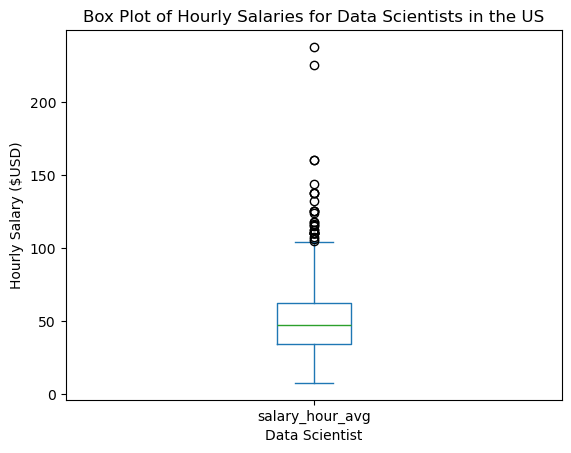

In [12]:
df_US = df[(df['job_country'] == 'United States') & (df['job_title_short']== 'Data Scientist')].copy()
df_US['salary_hour_avg'].dropna()
df_US['salary_hour_avg'].plot(kind='box', xlabel = 'Data Scientist', ylabel = 'Hourly Salary ($USD)', title = 'Box Plot of Hourly Salaries for Data Scientists in the US')
plt.show()

---

## 🟨 Comparison of Hourly Salaries for Data Analyst (2.18.2)

/var/folders/74/_sq0tgl174q5j9qsr6fx81lc0000gn/T/ipykernel_81315/729317084.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(countries_list, labels=countries)


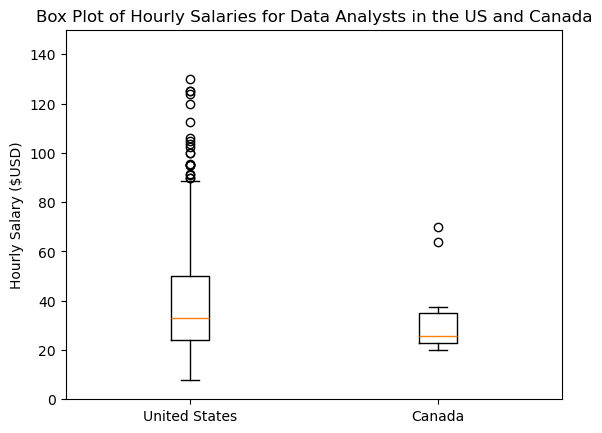

In [27]:
# Code Needed
countries = ['United States', 'Canada']
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'].isin(countries))].dropna(subset=['salary_hour_avg']).copy()

countries_list = [df_DA[df_DA['job_country'] == country]['salary_hour_avg'] for country in countries]
plt.boxplot(countries_list, labels=countries)
plt.xlabel('')
plt.ylabel('Hourly Salary ($USD)')
plt.ylim(0, 150)
plt.title('Box Plot of Hourly Salaries for Data Analysts in the US and Canada')
plt.show()

---

## 🟥 Comparison of Hourly Salaries in Canada (2.18.3)

/var/folders/74/_sq0tgl174q5j9qsr6fx81lc0000gn/T/ipykernel_81315/1116842749.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles)


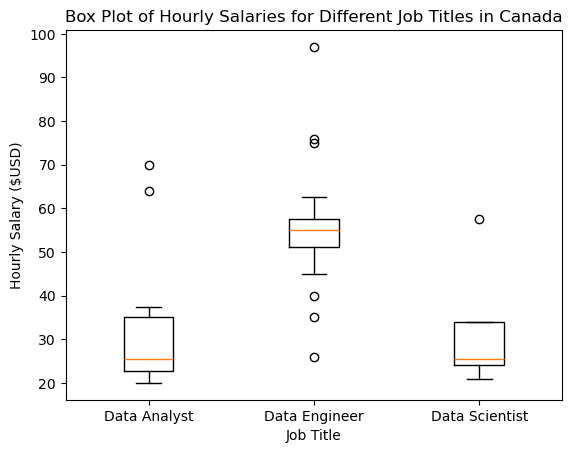

In [32]:
# Code Needed
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_post = df[(df['job_country'] == 'Canada') & (df['job_title_short'].isin(job_titles))].dropna(subset=['salary_hour_avg']).copy()
job_list = [df_post[df_post['job_title_short'] == title]['salary_hour_avg'] for title in job_titles]
plt.boxplot(job_list, labels=job_titles)
plt.xlabel('Job Title')
plt.ylabel('Hourly Salary ($USD)')
plt.title('Box Plot of Hourly Salaries for Different Job Titles in Canada')
plt.show()

---